In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# Load dataset
df = pd.read_csv('ScreenTime vs MentalWellness.csv')
# Menampilkan Preview dataset
print("Preview Data :", len(df))

Preview Data : 400


In [2]:
df.head()

,user_id,age,gender,occupation,work_mode,screen_time_hours,work_screen_hours,leisure_screen_hours,sleep_hours,sleep_quality_1_5,stress_level_0_10,productivity_0_100,exercise_minutes_per_week,social_hours_per_week,mental_wellness_index_0_100,Unnamed: 15
0,U0001,33,Female,Employed,Remote,10.79,5.44,5.35,6.63,1,9.3,44.7,127,0.7,9.3,NaN
1,U0002,28,Female,Employed,In-person,7.40,0.37,7.03,8.05,3,5.7,78.0,74,2.1,56.2,NaN
2,U0003,35,Female,Employed,Hybrid,9.78,1.09,8.69,6.48,1,9.1,51.8,67,8.0,3.6,NaN
3,U0004,42,Male,Employed,Hybrid,11.13,0.56,10.57,6.89,1,10.0,37.0,0,5.7,0.0,NaN
4,U0005,28,Male,Student,Remote,13.22,4.09,9.13,5.79,1,10.0,38.5,143,10.1,0.0,NaN


Fitur utama pada dataset (ScreenTime vs MentalWellness.csv)
- **user_id**: ID unik pada setiap responden
- **age**: Usia pengguna [berguna untuk melihat kelelahan berdasarkan umur]
- **gender**: Jenis kelamin [berguna untuk analisis perbedaan perilaku]
- **occupation**: Jenis pekerjaan [berguna untuk analisis segmentasi antara pelajar vs pekerja]
- **work_mode**: Jenis mode pekerjaan, contoh: remote, hybrid, onsite
- **screen_time_hours**: total waktu layar (jam/hari)
- **work_screen_hours**: total waktu bekerja
- **leisure_screen_hours**: total waktu untuk santai
- **sleep_hours**: total waktu tidur
- **sleep_quality_1_5**: kualitas waktu tidur skala 1-5
- **stress_level_0_10**: tingkatan stres sekala 0-10
- **productivity_0_100**: performa produktivitas skala 0-100
- **exercise_minutes_per_week**: waktu olahraga per minggu
- **social_hours_per_week**: waktu interaksi sosial per minggu
- **mental_wellness_index_0_100**: indeks kesehatan mental skala 0-100

# 2. **Data Assesing**

In [3]:
# Menampilkan beberapa info penting tentang dataset, seperti jumlah baris, kolom, tipe data, dan jumlah nilai yang tidak null.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 16 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   user_id                      400 non-null    object 
 1   age                          400 non-null    int64  
 2   gender                       400 non-null    object 
 3   occupation                   400 non-null    object 
 4   work_mode                    400 non-null    object 
 5   screen_time_hours            400 non-null    float64
 6   work_screen_hours            400 non-null    float64
 7   leisure_screen_hours         400 non-null    float64
 8   sleep_hours                  400 non-null    float64
 9   sleep_quality_1_5            400 non-null    int64  
 10  stress_level_0_10            400 non-null    float64
 11  productivity_0_100           400 non-null    float64
 12  exercise_minutes_per_week    400 non-null    int64  
 13  social_hours_per_wee

In [4]:
# Menampilkan statistik deskriptif untuk kolom numerik, seperti mean, median, standar deviasi, dan quartiles.
df.describe()

,age,screen_time_hours,work_screen_hours,leisure_screen_hours,sleep_hours,sleep_quality_1_5,stress_level_0_10,productivity_0_100,exercise_minutes_per_week,social_hours_per_week,mental_wellness_index_0_100,Unnamed: 15
count,400.00000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,0.0
mean,29.77750,9.024900,2.183075,6.841825,7.013175,1.397500,8.150500,54.306500,109.810000,7.905000,20.326750,NaN
std,7.46608,2.491058,1.931321,2.220896,0.852421,0.652348,2.094844,15.020054,70.007045,4.909632,20.376793,NaN
min,16.00000,1.000000,0.110000,0.890000,4.640000,1.000000,0.000000,20.600000,0.000000,0.000000,0.000000,NaN
25%,24.00000,7.372500,0.695000,5.460000,6.397500,1.000000,6.900000,43.600000,58.000000,4.575000,3.675000,NaN
50%,30.00000,9.090000,1.455000,6.700000,7.030000,1.000000,8.800000,51.750000,103.000000,7.750000,14.800000,NaN
75%,35.00000,10.495000,3.012500,8.417500,7.640000,2.000000,10.000000,63.000000,157.000000,11.025000,30.650000,NaN
max,60.00000,19.170000,12.040000,13.350000,9.740000,4.000000,10.000000,100.000000,372.000000,23.900000,97.000000,NaN


In [5]:
# Mengecek jumlah nilai yang hilang (null) di setiap kolom untuk mengetahui apakah ada missing values yang perlu diimputasi atau dihapus.
df.isnull().sum()

user_id                          0
age                              0
gender                           0
occupation                       0
work_mode                        0
screen_time_hours                0
work_screen_hours                0
leisure_screen_hours             0
sleep_hours                      0
sleep_quality_1_5                0
stress_level_0_10                0
productivity_0_100               0
exercise_minutes_per_week        0
social_hours_per_week            0
mental_wellness_index_0_100      0
Unnamed: 15                    400
dtype: int64

In [6]:
# Mengecek jumlah baris yang duplikat untuk memastikan tidak ada data yang terduplikasi yang dapat mempengaruhi hasil analisis.
df.duplicated().sum()

np.int64(0)

In [7]:
# Analisis nilai unik untuk kolom kategorikal
categorical_cols = ['gender', 'occupation', 'work_mode']
# Menampilkan jumlah nilai unik untuk setiap kolom kategorikal untuk memahami distribusi kategori dalam dataset.
for col in categorical_cols:
    print(f"\nValue counts for {col}:")
    print(df[col].value_counts())


Value counts for gender:
gender
Female              222
Male                170
Non-binary/Other      8
Name: count, dtype: int64

Value counts for occupation:
occupation
Employed         207
Student          107
Self-employed     45
Unemployed        27
Retired           14
Name: count, dtype: int64

Value counts for work_mode:
work_mode
Remote       150
Hybrid       146
In-person    104
Name: count, dtype: int64


In [8]:
# Menghapus kolom yang tidak diperlukan
df.drop(columns=['Unnamed: 15'], inplace=True)

In [9]:
## melihat struktur data setelah menghapus kolom yang tidak diperlukan
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   user_id                      400 non-null    object 
 1   age                          400 non-null    int64  
 2   gender                       400 non-null    object 
 3   occupation                   400 non-null    object 
 4   work_mode                    400 non-null    object 
 5   screen_time_hours            400 non-null    float64
 6   work_screen_hours            400 non-null    float64
 7   leisure_screen_hours         400 non-null    float64
 8   sleep_hours                  400 non-null    float64
 9   sleep_quality_1_5            400 non-null    int64  
 10  stress_level_0_10            400 non-null    float64
 11  productivity_0_100           400 non-null    float64
 12  exercise_minutes_per_week    400 non-null    int64  
 13  social_hours_per_wee

Distribusi Data Sebelum Cleaning


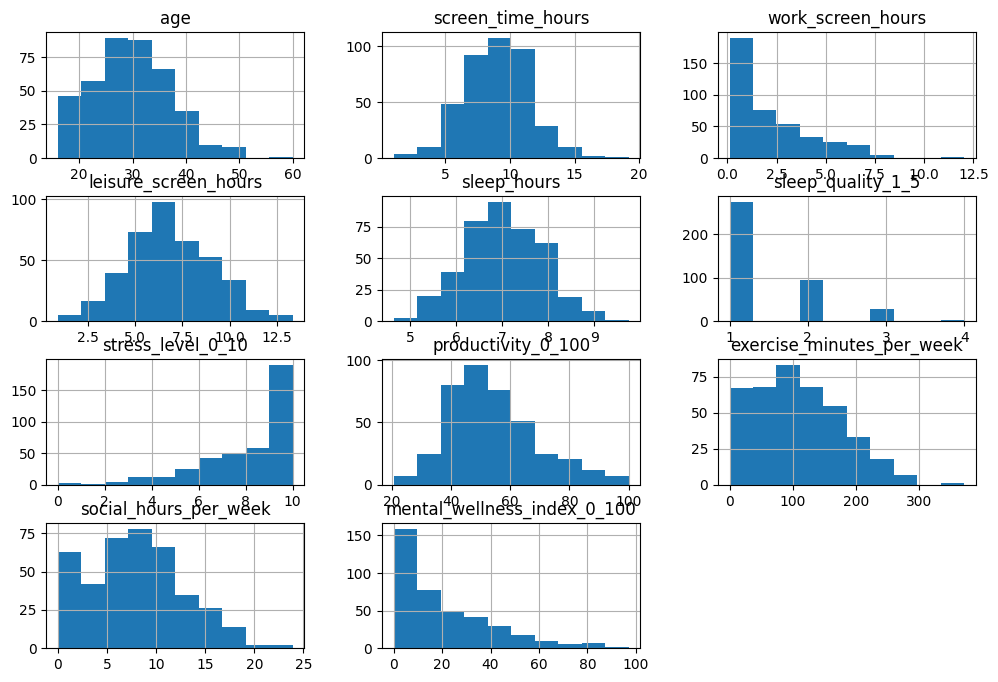

In [10]:
# Menampilkan distribusi data sebelum cleaning untuk melihat sebaran nilai pada setiap kolom numerik 
# dan mengidentifikasi adanya outliers atau distribusi yang tidak normal.
import matplotlib.pyplot as plt

print("Distribusi Data Sebelum Cleaning")
df.hist(figsize=(12,8))
plt.show()

# 3. **Data Cleaning**

In [11]:
# Membuat salinan dataset untuk proses cleaning agar data asli tetap utuh sebagai referensi.
df_clean = df.copy()

In [12]:
# Menghapus baris duplikat jika ada, untuk memastikan bahwa setiap entri dalam dataset adalah unik dan tidak mempengaruhi hasil analisis.
df_clean.drop_duplicates(inplace=True)

In [13]:
# Handle missing values if they exist (though we know there are none, this is a general step)
for col in df_clean.select_dtypes(include=['int64','float64']).columns:
    df_clean[col].fillna(df_clean[col].median(), inplace=True)

for col in df_clean.select_dtypes(include=['object']).columns:
    df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)

C:\Users\Administrator\AppData\Local\Temp\ipykernel_16744\1109066343.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean[col].fillna(df_clean[col].median(), inplace=True)
C:\Users\Administrator\AppData\Local\Temp\ipykernel_16744\1109066343.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always b

In [14]:
# Membersihkan data kategorikal dengan mengubah semua teks menjadi huruf kecil dan menghapus spasi ekstra untuk memastikan konsistensi dalam analisis.
for col in categorical_cols:
    df_clean[col] = df_clean[col].str.lower().str.strip()

In [15]:
# Ubah tipe data kolom kategorikal menjadi 'category' untuk mengoptimalkan penggunaan memori dan meningkatkan performa analisis.
for col in categorical_cols:
    df_clean[col] = df_clean[col].astype('category')

In [16]:
# Validate ranges

df_clean = df_clean[(df_clean['stress_level_0_10'] >= 0) & (df_clean['stress_level_0_10'] <= 10)]
df_clean = df_clean[df_clean['sleep_hours'] >= 0]
df_clean = df_clean[(df_clean['productivity_0_100'] >= 0) & (df_clean['productivity_0_100'] <= 100)]


In [17]:
# Handle outliers (IQR)
def remove_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[col] >= lower) & (df[col] <= upper)]

for col in ['screen_time_hours', 'sleep_hours', 'stress_level_0_10']:
    df_clean = remove_outliers(df_clean, col)

Distribusi Data Setelah Cleaning


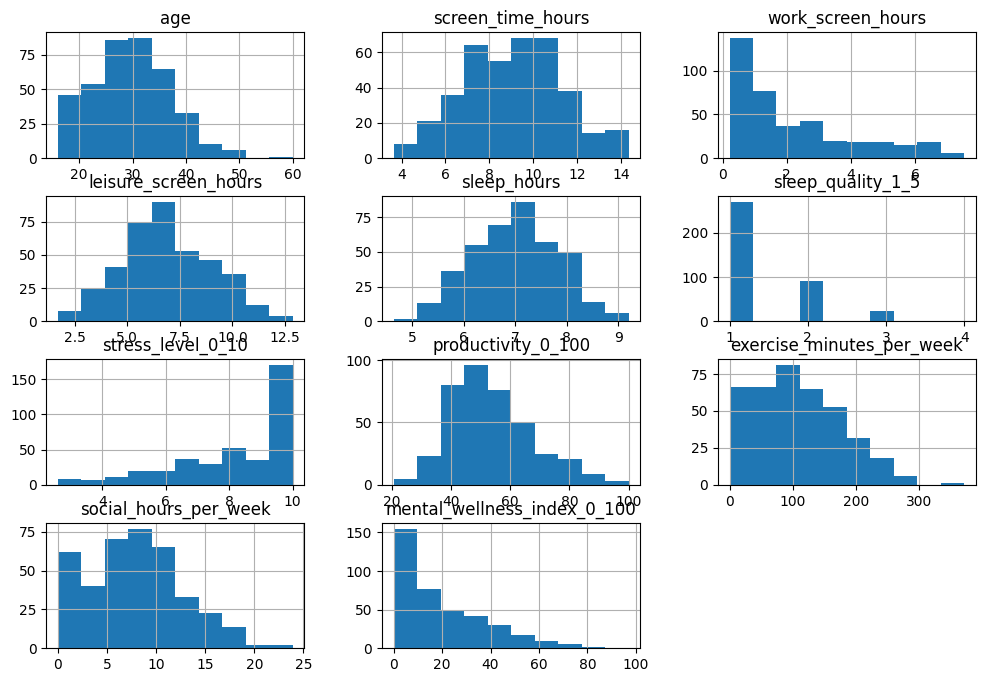

In [18]:
# Menampilkan distribusi data setelah cleaning untuk melihat perubahan sebaran nilai pada setiap kolom numerik setelah proses pembersihan data.
print("Distribusi Data Setelah Cleaning")
df_clean.hist(figsize=(12,8))
plt.show()

## **Memberikan perbandingan sebelum Data Cleaning dan sesudah Data Cleaning**

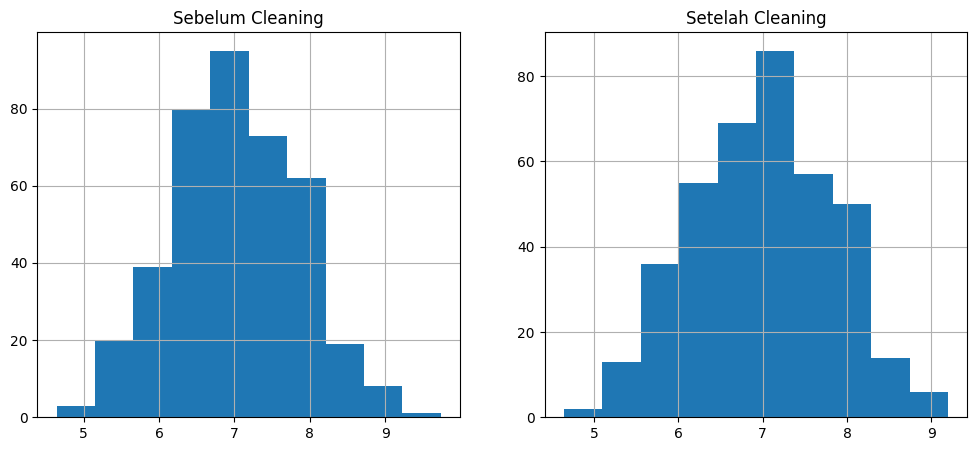

In [19]:
plt.figure(figsize=(12,5))

# Sebelum
plt.subplot(1,2,1)
df['sleep_hours'].hist()
plt.title("Sebelum Cleaning")

# Sesudah
plt.subplot(1,2,2)
df_clean['sleep_hours'].hist()
plt.title("Setelah Cleaning")

plt.show()

# 4. **Future Engginering**

In [20]:
# Membuat salinan dataset untuk proses cleaning agar data asli tetap utuh sebagai referensi.
df_fe = df_clean.copy()

In [21]:
# Total screen time
# Menggabungkan kolom 'work_screen_hours' dan 'leisure_screen_hours' untuk membuat fitur baru 'total_screen_time' yang mewakili total waktu layar yang digunakan setiap hari,
# yang dapat memberikan wawasan lebih dalam tentang hubungan antara penggunaan layar dan kesejahteraan mental.
df_fe['total_screen_time'] = df_fe['work_screen_hours'] + df_fe['leisure_screen_hours']

In [22]:
# Sleep deficit
# Mengukur defisit tidur dengan mengurangi jumlah jam tidur dari standar 8 jam, 
# dan memastikan bahwa nilai defisit tidak negatif (jika seseorang tidur lebih dari 8 jam, defisitnya adalah 0).
df_fe['sleep_deficit'] = 8 - df_fe['sleep_hours']
df_fe['sleep_deficit'] = df_fe['sleep_deficit'].apply(lambda x: x if x > 0 else 0)
# Jika memberikan nilai negatif, berarti tidur lebih dari 8 jam, jadi kita set defisitnya menjadi 0.

In [23]:
# Stress vs productivity ratio
# Mengukur tekanan relatif dengan membandingkan tingkat stres dengan produktivitas, dan menambahkan 1 pada produktivitas untuk menghindari pembagian dengan nol.
df_fe['stress_productivity_ratio'] = df_fe['stress_level_0_10'] / (df_fe['productivity_0_100'] + 1)

In [24]:
# Screen time category
# Mengkategorikan total waktu layar menjadi tiga kategori: 'low' untuk 0-4 jam, 'medium' untuk 4-8 jam, dan 'high' untuk lebih dari 8 jam,
# untuk memudahkan analisis hubungan antara penggunaan layar dan kesejahteraan mental.
df_fe['screen_time_category'] = pd.cut(
    df_fe['total_screen_time'],
    bins=[0, 4, 8, 24],
    labels=['low', 'medium', 'high']
)

# Sleep category
# Mengkategorikan jam tidur menjadi tiga kategori: 'poor' untuk 0-5 jam, 'normal' untuk 5-7 jam, dan 'good' untuk lebih dari 7 jam,
# untuk memudahkan analisis hubungan antara kualitas tidur dan kesejahteraan mental.
df_fe['sleep_category'] = pd.cut(
    df_fe['sleep_hours'],
    bins=[0, 5, 7, 10],
    labels=['poor', 'normal', 'good']
)

In [25]:
# Cognitive fatigue label (proxy)
def label_fatigue(row):
    if (row['sleep_hours'] < 5) and (row['stress_level_0_10'] > 7):
        return 'high'
    elif (row['sleep_hours'] < 6) and (row['stress_level_0_10'] > 5):
        return 'medium'
    else:
        return 'low'

df_fe['cognitive_fatigue'] = df_fe.apply(label_fatigue, axis=1)

In [ ]:
# Save cleaned and feature-engineered dataset
# Menyimpan dataset yang telah dibersihkan dan ditambahkan fitur baru ke dalam file CSV baru untuk digunakan dalam analisis lebih lanjut atau model machine learning.
df_fe.to_csv('cleaned_mental_wellness_1.csv', index=False)


In [27]:
# Menampilkan beberapa baris pertama dari dataset yang telah dibersihkan, dan 
# diberi fitur baru untuk memastikan bahwa proses feature engineering berjalan dengan benar, dan 
# untuk melihat struktur data akhir sebelum analisis lebih lanjut.
df_fe.head()

,user_id,age,gender,occupation,work_mode,screen_time_hours,work_screen_hours,leisure_screen_hours,sleep_hours,sleep_quality_1_5,...,productivity_0_100,exercise_minutes_per_week,social_hours_per_week,mental_wellness_index_0_100,total_screen_time,sleep_deficit,stress_productivity_ratio,screen_time_category,sleep_category,cognitive_fatigue
0,U0001,33,female,employed,remote,10.79,5.44,5.35,6.63,1,...,44.7,127,0.7,9.3,10.79,1.37,0.203501,high,normal,low
1,U0002,28,female,employed,in-person,7.40,0.37,7.03,8.05,3,...,78.0,74,2.1,56.2,7.40,0.00,0.072152,medium,good,low
2,U0003,35,female,employed,hybrid,9.78,1.09,8.69,6.48,1,...,51.8,67,8.0,3.6,9.78,1.52,0.172348,high,normal,low
3,U0004,42,male,employed,hybrid,11.13,0.56,10.57,6.89,1,...,37.0,0,5.7,0.0,11.13,1.11,0.263158,high,normal,low
4,U0005,28,male,student,remote,13.22,4.09,9.13,5.79,1,...,38.5,143,10.1,0.0,13.22,2.21,0.253165,high,normal,medium
